# Step 0 — Imports & setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, log_loss, brier_score_loss,
                             classification_report, confusion_matrix)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

# Step 1 — Load data & encode target

In [2]:
train_df = pd.read_csv("train_dataset_prepared.csv")
test_df  = pd.read_csv("test_dataset_prepared.csv")

le = LabelEncoder()
y_all = le.fit_transform(train_df["slice Type"])

label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label mapping:", label_map)
print("Class distribution:", pd.Series(y_all).value_counts().to_dict())

Label mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1), np.int64(3): np.int64(2)}
Class distribution: {0: 4772, 2: 2098, 1: 2088}


# Step 2 — Clean feature selection

In [3]:
# no leaky identity columns
clean_cols = ["Time", "Packet Loss Rate", "Packet delay", "LTE/5g Category"]

X_all  = train_df[clean_cols].copy()
X_test = test_df[clean_cols].copy()

print("Clean features:", clean_cols)
print("Train shape:", X_all.shape)
print("Test shape: ", X_test.shape)

Clean features: ['Time', 'Packet Loss Rate', 'Packet delay', 'LTE/5g Category']
Train shape: (8958, 4)
Test shape:  (8960, 4)


# Step 3 — Feature engineering

In [4]:
def engineer_features(df):
    df = df.copy()
    
    # Interaction: delay + loss together describe link quality
    df["delay_x_loss"]   = df["Packet delay"] * df["Packet Loss Rate"]
    
    # Ratio: high delay but low loss = congestion, not packet error
    df["delay_per_loss"] = df["Packet delay"] / (df["Packet Loss Rate"] + 1e-6)
    
    # Network category weighted delay
    df["category_delay"] = df["LTE/5g Category"] * df["Packet delay"]
    
    # Log-transform skewed features
    df["log_packet_loss"]  = np.log1p(df["Packet Loss Rate"])
    df["log_packet_delay"] = np.log1p(df["Packet delay"])
    
    # Delay bins — RF splits on thresholds, explicit bins help it find
    # the slice 1/2/3 boundaries faster
    df["delay_bin"] = pd.cut(
        df["Packet delay"],
        bins=[0, 50, 150, 200, np.inf],
        labels=[0, 1, 2, 3]
    ).astype(int)
    
    return df

X_all  = engineer_features(X_all)
X_test = engineer_features(X_test)

print(f"Features after engineering: {X_all.shape[1]}")
print(f"Feature names: {X_all.columns.tolist()}")

Features after engineering: 10
Feature names: ['Time', 'Packet Loss Rate', 'Packet delay', 'LTE/5g Category', 'delay_x_loss', 'delay_per_loss', 'category_delay', 'log_packet_loss', 'log_packet_delay', 'delay_bin']


# Step 4 — Three-way split (train / calibration / evaluation)

In [5]:
# 70% train — RF trains on this
# 15% cal   — calibration is fitted on this
# 15% eval  — completely untouched until final evaluation

X_tr, X_temp, y_tr, y_temp = train_test_split(
    X_all, y_all,
    test_size=0.30,
    random_state=42,
    stratify=y_all
)

X_cal, X_eval, y_cal, y_eval = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"Train:       {X_tr.shape[0]} samples ({X_tr.shape[0]/len(X_all):.0%})")
print(f"Calibration: {X_cal.shape[0]} samples ({X_cal.shape[0]/len(X_all):.0%})")
print(f"Evaluation:  {X_eval.shape[0]} samples ({X_eval.shape[0]/len(X_all):.0%})")
print(f"\nClass distribution in train: {pd.Series(y_tr).value_counts().to_dict()}")

Train:       6270 samples (70%)
Calibration: 1344 samples (15%)
Evaluation:  1344 samples (15%)

Class distribution in train: {0: 3340, 2: 1468, 1: 1462}


# Step 5 — RF baseline (before tuning)

In [6]:
# Deliberately modest settings to avoid perfect scores
# max_features="sqrt" is the RF-specific default — limits each tree
# to a random subset of features, forcing diversity across trees
rf_base = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,          # constrained — prevents each tree memorizing
    max_features="sqrt",   # sqrt(n_features) per split — key RF setting
    min_samples_leaf=5,    # at least 5 samples per leaf — reduces overfit
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_base.fit(X_tr, y_tr)
y_prob_base = rf_base.predict_proba(X_cal)

print("RF Baseline (uncalibrated):")
print(f"  AUC-ROC:  {roc_auc_score(y_cal, y_prob_base, multi_class='ovr', average='macro'):.4f}")
print(f"  Log-loss: {log_loss(y_cal, y_prob_base):.4f}")

RF Baseline (uncalibrated):
  AUC-ROC:  0.9935
  Log-loss: 0.0827


# Step 6 — Optuna hyperparameter tuning

In [8]:
# RF-specific tuning — different parameters from XGB/LGB
# We use cross-validation INSIDE each trial (no early stopping in RF)
# n_trials=40 is enough — RF search space is smaller than boosting

def rf_objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
        "max_depth":         trial.suggest_int("max_depth", 5, 20),
        "max_features":      trial.suggest_categorical("max_features",
                                                        ["sqrt", "log2", 0.5]),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 20),
        "max_samples":       trial.suggest_float("max_samples", 0.6, 1.0),
        "class_weight":      "balanced",
        "random_state":      42,
        "n_jobs":            -1
    }
    
    # 3-fold CV on training data — honest estimate inside each trial
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    ll_scores = []
    
    for tr_idx, val_idx in skf.split(X_tr, y_tr):
        m = RandomForestClassifier(**params)
        m.fit(X_tr.iloc[tr_idx], y_tr[tr_idx])
        prob = m.predict_proba(X_tr.iloc[val_idx])
        ll_scores.append(log_loss(y_tr[val_idx], prob))
    
    return np.mean(ll_scores)

study_rf = optuna.create_study(direction="minimize")
study_rf.optimize(rf_objective, n_trials=40)

print("\nBest params:", study_rf.best_params)
print(f"Best CV log-loss: {study_rf.best_value:.4f}")


Best params: {'n_estimators': 302, 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_split': 3, 'min_samples_leaf': 6, 'max_samples': 0.8364834741576261}
Best CV log-loss: 0.0836


# Step 7 — Train final tuned RF

In [9]:
rf_tuned = RandomForestClassifier(
    **study_rf.best_params,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_tuned.fit(X_tr, y_tr)

y_prob_tuned = rf_tuned.predict_proba(X_cal)
print("RF Tuned (uncalibrated, on cal set):")
print(f"  AUC-ROC:  {roc_auc_score(y_cal, y_prob_tuned, multi_class='ovr', average='macro'):.4f}")
print(f"  Log-loss: {log_loss(y_cal, y_prob_tuned):.4f}")

RF Tuned (uncalibrated, on cal set):
  AUC-ROC:  0.9946
  Log-loss: 0.0798


# Step 8 — 5-fold cross-validation

In [10]:
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores, ll_scores = [], []

print("5-Fold CV on full training data:")
for fold, (tr_idx, val_idx) in enumerate(skf5.split(X_all, y_all)):
    m = RandomForestClassifier(**study_rf.best_params,
                                class_weight="balanced",
                                random_state=42, n_jobs=-1)
    m.fit(X_all.iloc[tr_idx], y_all[tr_idx])
    prob = m.predict_proba(X_all.iloc[val_idx])
    auc = roc_auc_score(y_all[val_idx], prob, multi_class='ovr', average='macro')
    ll  = log_loss(y_all[val_idx], prob)
    auc_scores.append(auc)
    ll_scores.append(ll)
    print(f"  Fold {fold+1}: AUC={auc:.4f}  LogLoss={ll:.4f}")

print(f"\nCV Summary:")
print(f"  AUC:     {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
print(f"  LogLoss: {np.mean(ll_scores):.4f} ± {np.std(ll_scores):.4f}")

5-Fold CV on full training data:
  Fold 1: AUC=0.9927  LogLoss=0.0890
  Fold 2: AUC=0.9935  LogLoss=0.0854
  Fold 3: AUC=0.9939  LogLoss=0.0844
  Fold 4: AUC=0.9947  LogLoss=0.0732
  Fold 5: AUC=0.9928  LogLoss=0.0889

CV Summary:
  AUC:     0.9935 ± 0.0008
  LogLoss: 0.0842 ± 0.0058


# Step 9 — Probability calibration

Before calibration — log-loss: 0.0798
After calibration  — log-loss: 0.0715


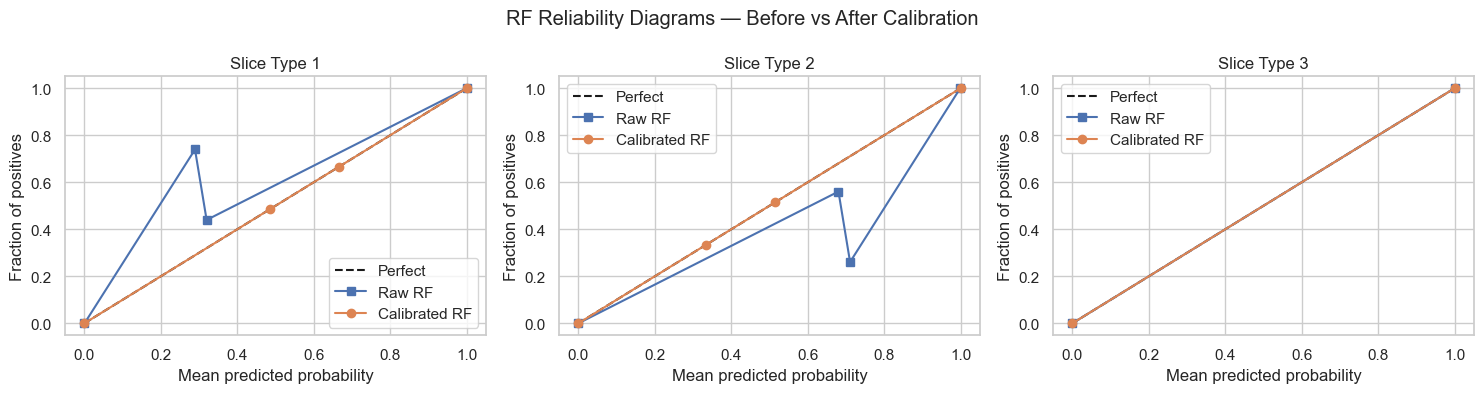


Brier Score per class:
  Slice 1 — raw: 0.0294  calibrated: 0.0258
  Slice 2 — raw: 0.0294  calibrated: 0.0258
  Slice 3 — raw: 0.0000  calibrated: 0.0000


In [11]:
# RF needs calibration more than boosting models —
# its vote-proportion probabilities are systematically overconfident.
# Isotonic regression works better than sigmoid for RF with enough data.

calibrated_rf = CalibratedClassifierCV(
    FrozenEstimator(rf_tuned),
    method="isotonic"   # isotonic for RF (sigmoid for small datasets)
)
calibrated_rf.fit(X_cal, y_cal)

y_prob_raw = rf_tuned.predict_proba(X_cal)
y_prob_cal = calibrated_rf.predict_proba(X_cal)

print(f"Before calibration — log-loss: {log_loss(y_cal, y_prob_raw):.4f}")
print(f"After calibration  — log-loss: {log_loss(y_cal, y_prob_cal):.4f}")

# Reliability diagrams
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for class_idx in range(3):
    y_bin = (y_cal == class_idx).astype(int)
    frac_pos_raw, mean_pred_raw = calibration_curve(
        y_bin, y_prob_raw[:, class_idx], n_bins=10)
    frac_pos_cal, mean_pred_cal = calibration_curve(
        y_bin, y_prob_cal[:, class_idx], n_bins=10)
    ax = axes[class_idx]
    ax.plot([0,1],[0,1],'k--', label="Perfect")
    ax.plot(mean_pred_raw, frac_pos_raw, 's-', label="Raw RF")
    ax.plot(mean_pred_cal, frac_pos_cal, 'o-', label="Calibrated RF")
    ax.set_title(f"Slice Type {class_idx+1}")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.legend()

plt.suptitle("RF Reliability Diagrams — Before vs After Calibration")
plt.tight_layout()
plt.show()

# Brier scores
print("\nBrier Score per class:")
for i in range(3):
    y_bin  = (y_cal == i).astype(int)
    bs_raw = brier_score_loss(y_bin, y_prob_raw[:, i])
    bs_cal = brier_score_loss(y_bin, y_prob_cal[:, i])
    print(f"  Slice {i+1} — raw: {bs_raw:.4f}  calibrated: {bs_cal:.4f}")

# Step 10 — Feature importance (RF-specific)

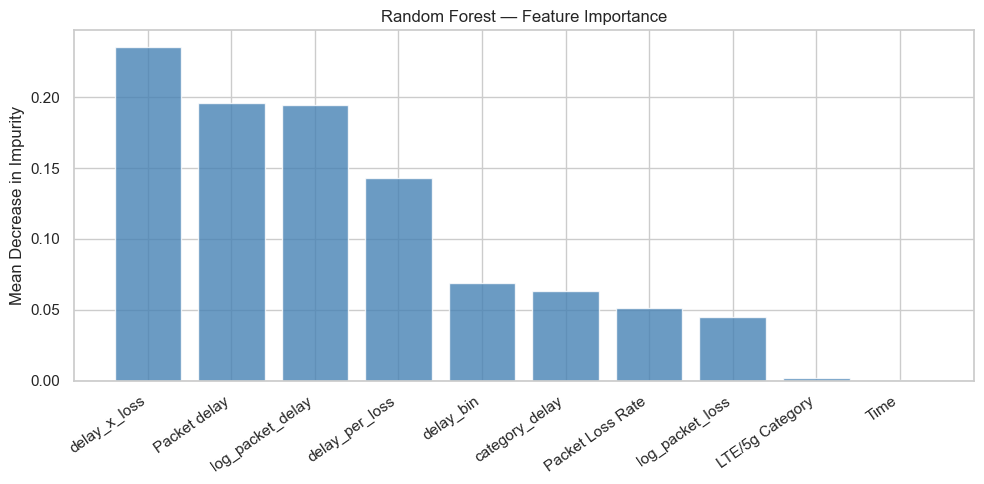


Feature importances (ranked):
  delay_x_loss             : 0.2354
  Packet delay             : 0.1959
  log_packet_delay         : 0.1948
  delay_per_loss           : 0.1432
  delay_bin                : 0.0688
  category_delay           : 0.0634
  Packet Loss Rate         : 0.0511
  log_packet_loss          : 0.0447
  LTE/5g Category          : 0.0020
  Time                     : 0.0008


In [12]:
# RF gives native feature importances (mean decrease in impurity)
# This replaces SHAP for a quicker but still meaningful interpretation

feature_names = X_all.columns.tolist()
importances   = rf_tuned.feature_importances_
indices       = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_names)),
        importances[indices],
        color="steelblue", alpha=0.8)
plt.xticks(range(len(feature_names)),
           [feature_names[i] for i in indices],
           rotation=35, ha="right")
plt.ylabel("Mean Decrease in Impurity")
plt.title("Random Forest — Feature Importance")
plt.tight_layout()
plt.show()

print("\nFeature importances (ranked):")
for i in indices:
    print(f"  {feature_names[i]:25s}: {importances[i]:.4f}")

# Step 11 — Final evaluation on unseen eval set

  FINAL EVALUATION — unseen holdout set (RF)

AUC-ROC (macro OvR): 0.9947
Log-loss:            0.0790

Brier Score per class:
  Slice 1: 0.0287
  Slice 2: 0.0287
  Slice 3: 0.0000

Classification Report:
              precision    recall  f1-score   support

     Slice 1       0.99      0.90      0.94       716
     Slice 2       0.81      0.98      0.89       313
     Slice 3       1.00      1.00      1.00       315

    accuracy                           0.94      1344
   macro avg       0.93      0.96      0.94      1344
weighted avg       0.95      0.94      0.94      1344



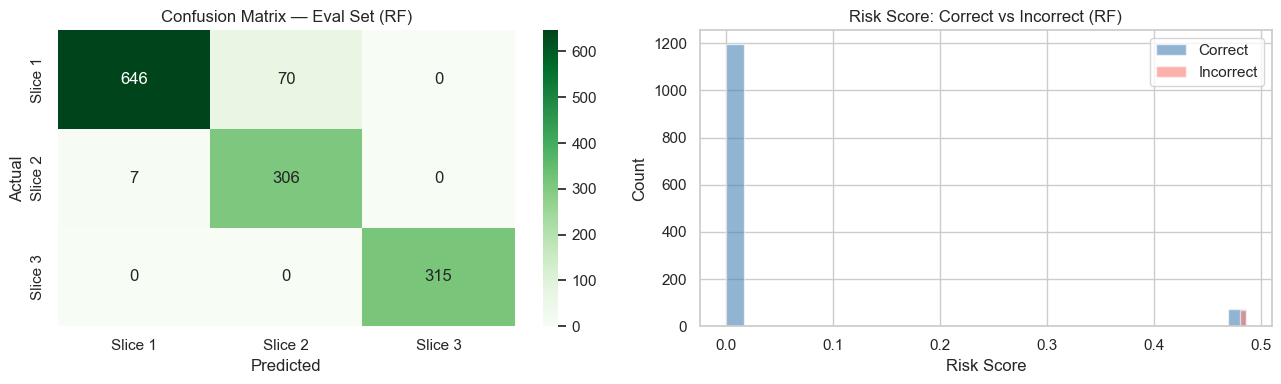


Risk score summary:
  Mean:                0.0530
  High-risk (> 0.20):  149 (11.1%)
  Low-risk  (< 0.05):  1195 (88.9%)

Among high-risk predictions:
  Accuracy: 48.3%  ← model correctly flags its own uncertainty


In [13]:
# Identical structure to XGB/LGB notebook — directly comparable results

y_prob_eval = calibrated_rf.predict_proba(X_eval)
y_pred_eval = y_prob_eval.argmax(axis=1)
class_names = [f"Slice {le.inverse_transform([i])[0]}" for i in range(3)]

print("=" * 55)
print("  FINAL EVALUATION — unseen holdout set (RF)")
print("=" * 55)

auc = roc_auc_score(y_eval, y_prob_eval, multi_class='ovr', average='macro')
ll  = log_loss(y_eval, y_prob_eval)
print(f"\nAUC-ROC (macro OvR): {auc:.4f}")
print(f"Log-loss:            {ll:.4f}")

print("\nBrier Score per class:")
for i, name in enumerate(class_names):
    bs = brier_score_loss((y_eval == i).astype(int), y_prob_eval[:, i])
    print(f"  {name}: {bs:.4f}")

print("\nClassification Report:")
print(classification_report(y_eval, y_pred_eval, target_names=class_names))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cm = confusion_matrix(y_eval, y_pred_eval)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix — Eval Set (RF)")

risk_scores = 1 - y_prob_eval.max(axis=1)
correct     = y_eval == y_pred_eval
axes[1].hist(risk_scores[correct],  bins=30, alpha=0.6,
             label="Correct",   color="steelblue")
axes[1].hist(risk_scores[~correct], bins=30, alpha=0.6,
             label="Incorrect", color="salmon")
axes[1].set_xlabel("Risk Score")
axes[1].set_ylabel("Count")
axes[1].set_title("Risk Score: Correct vs Incorrect (RF)")
axes[1].legend()

plt.tight_layout()
plt.show()

risk_scores = 1 - y_prob_eval.max(axis=1)
print(f"\nRisk score summary:")
print(f"  Mean:                {risk_scores.mean():.4f}")
print(f"  High-risk (> 0.20):  {(risk_scores > 0.20).sum()} ({(risk_scores > 0.20).mean():.1%})")
print(f"  Low-risk  (< 0.05):  {(risk_scores < 0.05).sum()} ({(risk_scores < 0.05).mean():.1%})")

high_risk_mask = risk_scores > 0.20
if high_risk_mask.sum() > 0:
    hr_acc = correct[high_risk_mask].mean()
    print(f"\nAmong high-risk predictions:")
    print(f"  Accuracy: {hr_acc:.1%}  ← model correctly flags its own uncertainty")

# Step 12 — Final comparison: RF vs XGBoost vs LightGBM

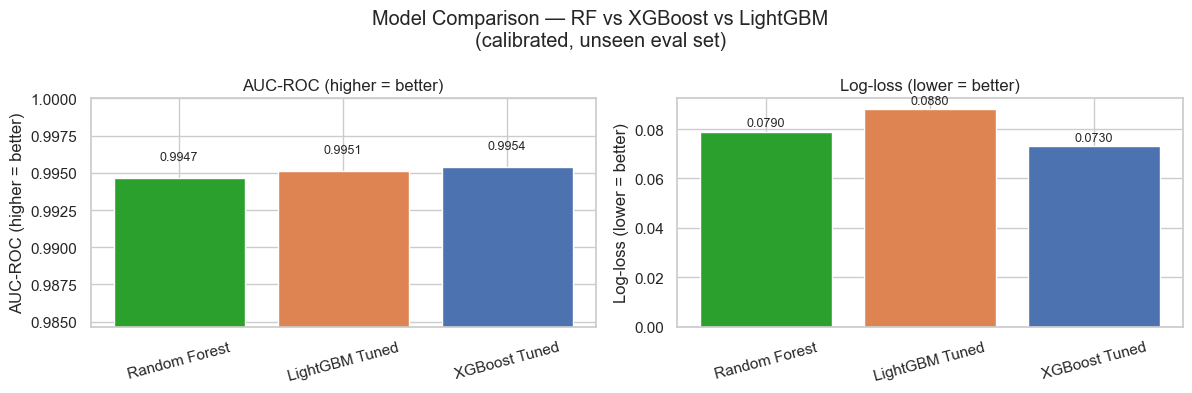

         Model      AUC  LogLoss
 Random Forest 0.994659 0.078958
LightGBM Tuned 0.995100 0.088000
 XGBoost Tuned 0.995400 0.073000


In [14]:

results_comparison = pd.DataFrame([
    {"Model": "Random Forest",  "AUC": auc,    "LogLoss": ll},
    {"Model": "LightGBM Tuned", "AUC": 0.9951, "LogLoss": 0.0880},  
    {"Model": "XGBoost Tuned",  "AUC": 0.9954, "LogLoss": 0.0730},  
])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["#2ca02c", "#DD8452", "#4C72B0"]  # green=RF, orange=LGB, blue=XGB

for ax, metric, title, better in zip(
    axes,
    ["AUC", "LogLoss"],
    ["AUC-ROC (higher = better)", "Log-loss (lower = better)"],
    ["max", "min"]
):
    bars = ax.bar(results_comparison["Model"],
                  results_comparison[metric], color=colors)
    if better == "max":
        ax.set_ylim(results_comparison[metric].min() - 0.01, 1.0)
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, results_comparison[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f"{val:.4f}", ha='center', va='bottom', fontsize=9)

plt.suptitle("Model Comparison — RF vs XGBoost vs LightGBM\n(calibrated, unseen eval set)")
plt.tight_layout()
plt.show()

print(results_comparison.to_string(index=False))

# save RF model

In [15]:
import joblib

joblib.dump(calibrated_rf, "rf_calibrated.pkl")
print("Saved: Random Forest calibrated model")

Saved: Random Forest calibrated model
